In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from scipy.stats import f_oneway, ttest_ind
import pingouin as pg
import statsmodels.formula.api as smf
from sklearn.utils import resample
from statsmodels.miscmodels.ordinal_model import OrderedModel


Data Preperation

In [ ]:
# Load CSV into a DataFrame (email addresses have been removed for privacy)
df = pd.read_csv("survey.csv")

#how many participants started the survey
print(len(df))

#how many completed it
print(df['Q65'].count())

167
130


In [73]:

# drop participants that did not agree to participate
df = df[df['Q4'] == 'Ich stimme zu']

# Remove any under 18
df = df[df['Q1'] != 'unter 18']

# Remove rows with missing values in trust questions
required_columns = ['Q49_1', 'Q49_2', 'Q49_3', 'Q49_4', 'Q49_6']
df = df.dropna(subset=required_columns)

# remove participants that did not pass attention check
df = df[df['Q49_5'] == 'Stimme voll zu']

#print how many N are left 
print(len(df))

111


In [36]:
# create the trust scale by averaging responses
LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

df["Q49_1_num"] = df["Q49_1"].map(LIKERT_MAP)
df["Q49_2_num"] = df["Q49_2"].map(LIKERT_MAP)
df["Q49_3_r"]   = 6 - df["Q49_3"].map(LIKERT_MAP)  # reverse scored
df["Q49_4_num"] = df["Q49_4"].map(LIKERT_MAP)

df["trust_score"] = df[["Q49_1_num", "Q49_2_num", "Q49_3_r", "Q49_4_num"]].mean(axis=1)

In [ ]:
## explore demographics
#political orientation
df['Q6_1'] = pd.to_numeric(df['Q6_1'], errors='coerce')
print(df['Q6_1'].agg(['count', 'mean', 'median', 'std']))

# education
target_values = [
    "Hochschul- oder Fachabschluss (MA, MS, MBA, PhD, JD, MD, DDS usw.)",
    "Universität, Bachelor-Abschluss", "Teilweise Universität, aber ohne Abschluss"
]

print(df['Q57'].isin(target_values).sum())

count     107.000000
mean        2.598131
median      2.000000
std         1.800733
Name: Q6_1, dtype: float64
90


In [67]:
## How many participants believe the chatbot may make sporadic errors
high_trust = df["Q49_3"].str.strip().isin(["Stimme eher zu", "Stimme voll zu"])
pct = high_trust.sum() / df["Q49_3"].notna().sum() * 100
print(f"{pct:.1f}% of participants either agree or fully agree with Q49_3")

89.2% of participants either agree or fully agree with Q49_3


Statistical Tests

In [38]:
## Cronbachs alpha to justify composite trust scale
df_alpha = df[["Q49_1", "Q49_2", "Q49_3", "Q49_4"]].copy()
for q in ["Q49_1", "Q49_2", "Q49_3", "Q49_4"]:
    df_alpha[q] = df_alpha[q].map(LIKERT_MAP)

df_alpha["Q49_3"] = 6 - df_alpha["Q49_3"]  # reverse score

df_alpha = df_alpha.dropna()

alpha = pg.cronbach_alpha(df_alpha)
print(f"Cronbach's alpha: {alpha[0]:.3f}")
print(f"95% CI: [{alpha[1][0]:.3f}, {alpha[1][1]:.3f}]")

Cronbach's alpha: 0.753
95% CI: [0.668, 0.821]


In [ ]:
# Linear regression for trust scale (control vs other conditions) (SRQ1)
df_model = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_model = df_model.dropna(subset=["trust_score", "condition"])

#Linear Regression
ols_a = smf.ols("trust_score ~ C(condition, Treatment(reference='A'))", data=df_model).fit()
print(ols_a.summary())


#Bootstrap CIs
N_BOOTSTRAP = 1000

for ref, label in [("A", "A as reference")]:
    coef_store = []
    for i in range(N_BOOTSTRAP):
        sample = resample(df_model, random_state=i)
        try:
            m = smf.ols(f"trust_score ~ C(condition, Treatment(reference='{ref}'))", 
                        data=sample).fit()
            coef_store.append(m.params[1:4].values)
        except Exception:
            continue

    coef_df = pd.DataFrame(coef_store)
    print(f"\n  Bootstrap 95% CI: {label} ")
    cols = [c for c in ols_a.params.index if "condition" in c] if ref == "A" else \
           [c for c in ols_c.params.index if "condition" in c] if ref == "C" else \
           [c for c in ols_b.params.index if "condition" in c]
    for j, col in enumerate(cols):
        lower = np.percentile(coef_df[j], 2.5)
        upper = np.percentile(coef_df[j], 97.5)
        print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")

                            OLS Regression Results                            
Dep. Variable:            trust_score   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     3.775
Date:                Mon, 22 Jun 2026   Prob (F-statistic):             0.0128
Time:                        21:40:24   Log-Likelihood:                -121.61
No. Observations:                 111   AIC:                             251.2
Df Residuals:                     107   BIC:                             262.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
## regression and bootstrap for Q49_1 (SRQ1)

LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

df_model = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_model["Q49_1"] = df_model["Q49_1"].map(LIKERT_MAP)
df_model = df_model.dropna(subset=["Q49_1", "condition"])
df_model["Q49_1"] = df_model["Q49_1"].astype(int)

# Dummy encode condition with A as reference
df_model = pd.get_dummies(df_model, columns=["condition"], drop_first=False)
df_model = df_model.drop(columns=["condition_A"]) 
condition_cols = ["condition_B", "condition_C", "condition_D"]
df_model[condition_cols] = df_model[condition_cols].astype(int)

#fit model
model = OrderedModel(df_model["Q49_1"], df_model[condition_cols], distr="logit")
result = model.fit(method="bfgs", disp=False)
print(result.summary())

#Bootstrap
N_BOOTSTRAP = 1000
coef_store = []

for i in range(N_BOOTSTRAP):
    sample = resample(df_model, random_state=i)
    try:
        m = OrderedModel(sample["Q49_1"], sample[condition_cols], distr="logit")
        r = m.fit(method="bfgs", disp=False)
        coef_store.append(r.params[condition_cols].values)
    except Exception:
        continue

coef_df = pd.DataFrame(coef_store, columns=condition_cols)

print("\n Bootstrap 95% Confidence Intervals")
for col in condition_cols:
    lower = np.percentile(coef_df[col], 2.5)
    upper = np.percentile(coef_df[col], 97.5)
    print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")

=== Ordinal Logistic Regression (original data) ===
                             OrderedModel Results                             
Dep. Variable:                  Q49_1   Log-Likelihood:                -146.15
Model:                   OrderedModel   AIC:                             306.3
Method:            Maximum Likelihood   BIC:                             325.2
Date:                Mon, 22 Jun 2026                                         
Time:                        21:43:37                                         
No. Observations:                 110                                         
Df Residuals:                     103                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
condition_B     0.3922      0.513      0.764      0.445      -0.614       1.3

In [58]:
## regression and bootstrap for Q49_2 (SRQ1)


LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

df_model = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_model["Q49_2"] = df_model["Q49_2"].map(LIKERT_MAP)
df_model = df_model.dropna(subset=["Q49_2", "condition"])
df_model["Q49_2"] = df_model["Q49_2"].astype(int)

# Dummy encode condition with A as reference
df_model = pd.get_dummies(df_model, columns=["condition"], drop_first=False)
df_model = df_model.drop(columns=["condition_A"]) 
condition_cols = ["condition_B", "condition_C", "condition_D"]
df_model[condition_cols] = df_model[condition_cols].astype(int)

#fit model
model = OrderedModel(df_model["Q49_2"], df_model[condition_cols], distr="logit")
result = model.fit(method="bfgs", disp=False)
print(result.summary())

#bootstrap
N_BOOTSTRAP = 1000
coef_store = []

for i in range(N_BOOTSTRAP):
    sample = resample(df_model, random_state=i)
    try:
        m = OrderedModel(sample["Q49_2"], sample[condition_cols], distr="logit")
        r = m.fit(method="bfgs", disp=False)
        coef_store.append(r.params[condition_cols].values)
    except Exception:
        continue

coef_df = pd.DataFrame(coef_store, columns=condition_cols)

print("\n Bootstrap 95% Confidence Intervals")
for col in condition_cols:
    lower = np.percentile(coef_df[col], 2.5)
    upper = np.percentile(coef_df[col], 97.5)
    print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")

                             OrderedModel Results                             
Dep. Variable:                  Q49_2   Log-Likelihood:                -156.73
Model:                   OrderedModel   AIC:                             327.5
Method:            Maximum Likelihood   BIC:                             346.4
Date:                Mon, 22 Jun 2026                                         
Time:                        23:47:26                                         
No. Observations:                 111                                         
Df Residuals:                     104                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
condition_B     1.2629      0.500      2.524      0.012       0.282       2.243
condition_C     0.5453      0.488      1.118     

In [59]:
## regression and bootstrap for Q49_3 (SRQ1)

import numpy as np
import pandas as pd
from sklearn.utils import resample
from statsmodels.miscmodels.ordinal_model import OrderedModel

LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

df_model = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_model["Q49_3"] = df_model["Q49_3"].map(LIKERT_MAP)
df_model = df_model.dropna(subset=["Q49_3", "condition"])
df_model["Q49_3"] = df_model["Q49_3"].astype(int)

# Dummy encode condition with A as reference
df_model = pd.get_dummies(df_model, columns=["condition"], drop_first=False)
df_model = df_model.drop(columns=["condition_A"]) 
condition_cols = ["condition_B", "condition_C", "condition_D"]
df_model[condition_cols] = df_model[condition_cols].astype(int)

# fit model
model = OrderedModel(df_model["Q49_3"], df_model[condition_cols], distr="logit")
result = model.fit(method="bfgs", disp=False)
print(result.summary())

#bootstrap
N_BOOTSTRAP = 1000
coef_store = []

for i in range(N_BOOTSTRAP):
    sample = resample(df_model, random_state=i)
    try:
        m = OrderedModel(sample["Q49_3"], sample[condition_cols], distr="logit")
        r = m.fit(method="bfgs", disp=False)
        coef_store.append(r.params[condition_cols].values)
    except Exception:
        continue

coef_df = pd.DataFrame(coef_store, columns=condition_cols)

print("\n Bootstrap 95% Confidence Intervals")
for col in condition_cols:
    lower = np.percentile(coef_df[col], 2.5)
    upper = np.percentile(coef_df[col], 97.5)
    print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")

                             OrderedModel Results                             
Dep. Variable:                  Q49_3   Log-Likelihood:                -98.229
Model:                   OrderedModel   AIC:                             208.5
Method:            Maximum Likelihood   BIC:                             224.7
Date:                Mon, 22 Jun 2026                                         
Time:                        23:54:31                                         
No. Observations:                 110                                         
Df Residuals:                     104                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
condition_B    -1.0271      0.591     -1.738      0.082      -2.185       0.131
condition_C    -0.2051      0.599     -0.342     

In [ ]:
## regression and bootstrap for Q49_4 (SRQ1)


LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

df_model = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_model["Q49_4"] = df_model["Q49_4"].map(LIKERT_MAP)
df_model = df_model.dropna(subset=["Q49_4", "condition"])
df_model["Q49_4"] = df_model["Q49_4"].astype(int)

# Dummy encode condition with A as reference
df_model = pd.get_dummies(df_model, columns=["condition"], drop_first=False)
df_model = df_model.drop(columns=["condition_A"])  
condition_cols = ["condition_B", "condition_C", "condition_D"]
df_model[condition_cols] = df_model[condition_cols].astype(int)

#fit model
model = OrderedModel(df_model["Q49_4"], df_model[condition_cols], distr="logit")
result = model.fit(method="bfgs", disp=False)
print("=== Ordinal Logistic Regression (original data) ===")
print(result.summary())

#bootstrap
N_BOOTSTRAP = 1000
coef_store = []

for i in range(N_BOOTSTRAP):
    sample = resample(df_model, random_state=i)
    try:
        m = OrderedModel(sample["Q49_4"], sample[condition_cols], distr="logit")
        r = m.fit(method="bfgs", disp=False)
        coef_store.append(r.params[condition_cols].values)
    except Exception:
        continue

coef_df = pd.DataFrame(coef_store, columns=condition_cols)

print("\n Bootstrap 95% Confidence Intervals")
for col in condition_cols:
    lower = np.percentile(coef_df[col], 2.5)
    upper = np.percentile(coef_df[col], 97.5)
    print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")

=== Ordinal Logistic Regression (original data) ===
                             OrderedModel Results                             
Dep. Variable:                  Q49_4   Log-Likelihood:                -147.70
Model:                   OrderedModel   AIC:                             309.4
Method:            Maximum Likelihood   BIC:                             328.4
Date:                Mon, 22 Jun 2026                                         
Time:                        23:57:44                                         
No. Observations:                 111                                         
Df Residuals:                     104                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
condition_B     1.7364      0.534      3.254      0.001       0.691       2.7

In [70]:
## Kruskal Wallis test for link click count (SRQ2)

df_kw = df[df["condition"].isin(["A", "B", "C", "D"])].copy()
df_kw["link_click_count"] = pd.to_numeric(df_kw["link_click_count"], errors="coerce")
df_kw = df_kw.dropna(subset=["link_click_count", "condition"])

groups = [df_kw[df_kw["condition"] == c]["link_click_count"].values for c in ["A", "B", "C", "D"]]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis: H={stat:.3f}, p={p:.4f}")

if p < 0.05:
    print("Significant. Next step: Mann-Whitney U tests")
else:
    print("Not significant. No pairwise tests needed.")

Kruskal-Wallis: H=2.629, p=0.4524
Not significant. No pairwise tests needed.


In [62]:
## ANOVA omnibus on Conditions B,C and D (SRQ3)

df_model = df[df["condition"].isin(["B", "C", "D"])].copy()
df_model = df_model.dropna(subset=["trust_score", "condition"])

print("=" * 50)
print("  One-Way ANOVA (Trust Score)")
print("=" * 50)

groups = [
    df_model[df_model["condition"] == c]["trust_score"].values
    for c in ["B", "C", "D"]
]

F, p = f_oneway(*groups)

print(f"\nOne-Way ANOVA: F={F:.3f}, p={p:.4f}")

  One-Way ANOVA (Trust Score)

One-Way ANOVA: F=4.863, p=0.0101


In [ ]:
##Linear Regression for B,C and D (SRQ3)

df_bcd = df[df["condition"].isin(["B", "C", "D"])].copy()
df_bcd = df_bcd.dropna(subset=["trust_score", "condition"])

N_BOOTSTRAP = 1000

for ref in ["C", "B"]:
    print(f"\n{'=' * 50}")
    print(f"  Linear Regression ({ref} as reference)")
    print(f"{'=' * 50}")

    ols = smf.ols(f"trust_score ~ C(condition, Treatment(reference='{ref}'))",
                  data=df_bcd).fit()
    print(ols.summary())

    # Bootstrap CIs
    coef_store = []
    for i in range(N_BOOTSTRAP):
        sample = resample(df_bcd, random_state=i)
        try:
            m = smf.ols(f"trust_score ~ C(condition, Treatment(reference='{ref}'))",
                        data=sample).fit()
            coef_store.append(m.params[1:].values)
        except Exception:
            continue

    coef_df = pd.DataFrame(coef_store)
    cols = [c for c in ols.params.index if "condition" in c]
    print(f"\nBootstrap 95% CI — {ref} as reference:")
    for j, col in enumerate(cols):
        lower = np.percentile(coef_df[j], 2.5)
        upper = np.percentile(coef_df[j], 97.5)
        print(f"  {col}: 95% CI [{lower:.3f}, {upper:.3f}]")


  Linear Regression (C as reference)
                            OLS Regression Results                            
Dep. Variable:            trust_score   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     4.863
Date:                Tue, 23 Jun 2026   Prob (F-statistic):             0.0101
Time:                        13:59:43   Log-Likelihood:                -93.344
No. Observations:                  86   AIC:                             192.7
Df Residuals:                      83   BIC:                             200.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [71]:
## correlation between trust_score and link click count
from scipy.stats import spearmanr

df_corr = df.copy()
df_corr["link_click_count"] = pd.to_numeric(df_corr["link_click_count"], errors="coerce")
df_corr = df_corr.dropna(subset=["trust_score", "link_click_count"])

rho, p = spearmanr(df_corr["trust_score"], df_corr["link_click_count"])
print(f"Spearman's ρ = {rho:.3f}, p = {p:.4f}")

Spearman's ρ = -0.343, p = 0.0002


Visualizations

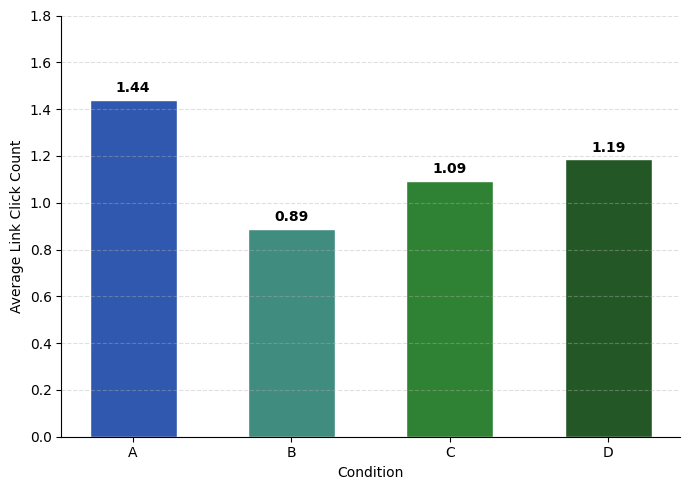

In [42]:
# Bar chart of average link_click_count
CONDITIONS = ["A", "B", "C", "D"]
COLORS = [ "#3058AE", "#408D80", "#2F8233", "#235826"]

df_plot = df[df["condition"].isin(CONDITIONS)].copy()
df_plot["link_click_count"] = pd.to_numeric(df_plot["link_click_count"], errors="coerce")
df_plot = df_plot.dropna(subset=["link_click_count"])

avg_clicks = df_plot.groupby("condition")["link_click_count"].mean().reindex(CONDITIONS)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(CONDITIONS, avg_clicks, color=COLORS, width=0.55, edgecolor="white")
for bar, val in zip(bars, avg_clicks):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlabel("Condition"); ax.set_ylabel("Average Link Click Count")
ax.set_ylim(0, avg_clicks.max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()


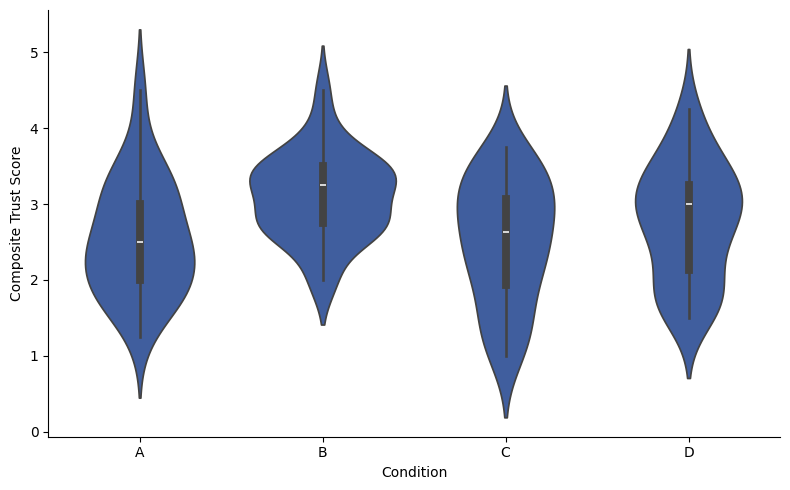

In [43]:

## Violin plots for trust scores by condition
LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

CONDITIONS = ["A", "B", "C", "D"]

df_plot = df[df["condition"].isin(CONDITIONS)].copy()
df_plot["link_click_count"] = pd.to_numeric(df_plot["link_click_count"], errors="coerce")
df_plot["trust_score"] = df_plot["trust_score"]

# ── Trust score by condition ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_plot, x="condition", y="trust_score", order=CONDITIONS,
                inner="box", ax=ax, color="#3058AE")
ax.set_xlabel("Condition"); ax.set_ylabel("Composite Trust Score")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()



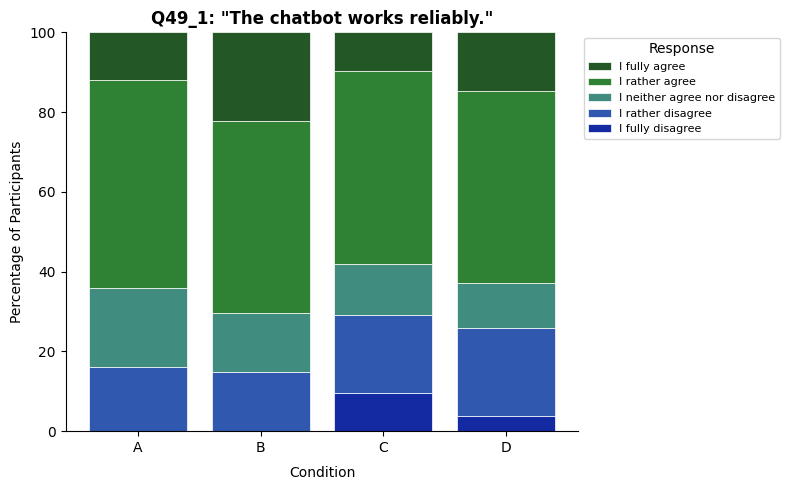

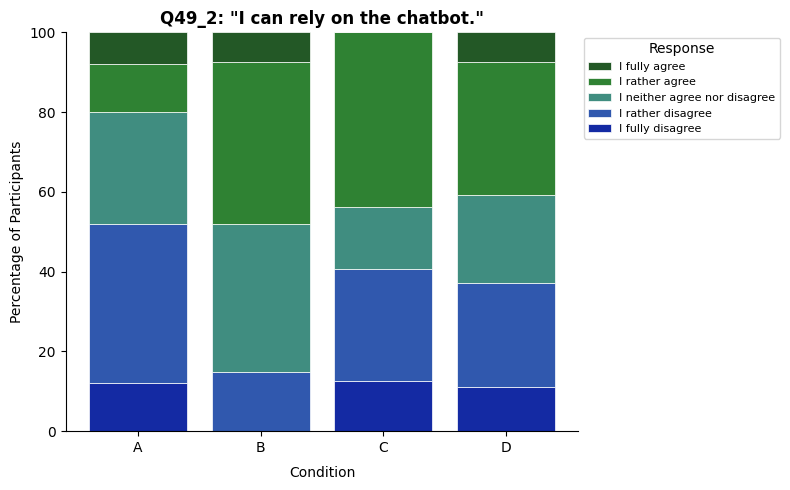

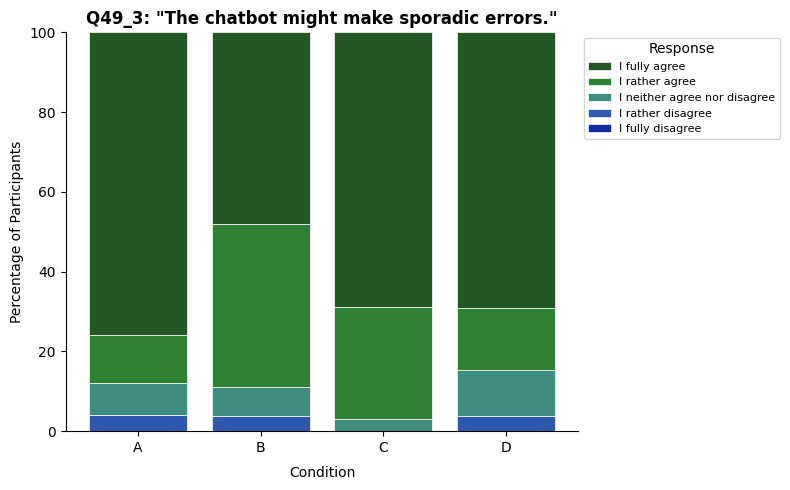

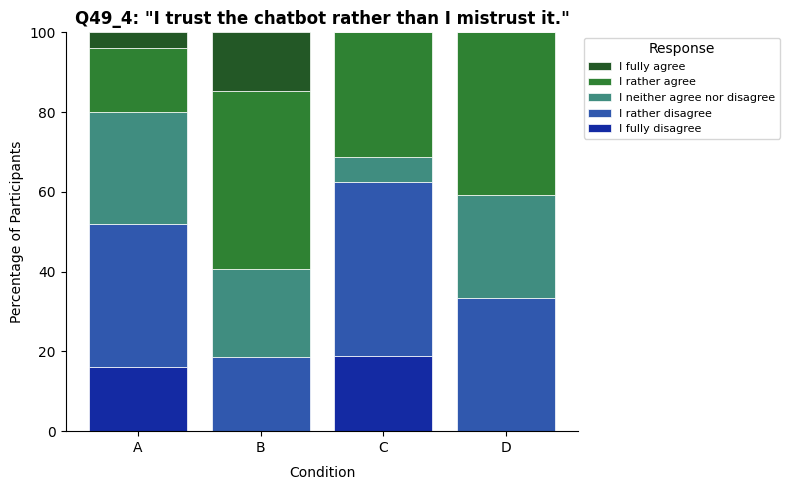

In [44]:
## stacked bar charts for Q49_1 - Q49_4

LIKERT_MAP = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Stimme weder zu noch nicht zu": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
}

LIKERT_LABELS_EN = [
    "I fully disagree",
    "I rather disagree",
    "I neither agree nor disagree",
    "I rather agree",
    "I fully agree",
]
TITLES = {
    "Q49_1": 'Q49_1: "The chatbot works reliably."',
    "Q49_2": 'Q49_2: "I can rely on the chatbot."',
    "Q49_3": 'Q49_3: "The chatbot might make sporadic errors."',
    "Q49_4": 'Q49_4: "I trust the chatbot rather than I mistrust it."',
}

CONDITIONS = ["A", "B", "C", "D"]
COLORS = ["#142AA3", "#3058AE", "#408D80", "#2F8233", "#235826"]

df_plot = df[df["condition"].isin(CONDITIONS)].copy()
for q in ["Q49_1", "Q49_2", "Q49_3", "Q49_4"]:
    df_plot[q] = df_plot[q].map(LIKERT_MAP)

for q in ["Q49_1", "Q49_2", "Q49_3", "Q49_4"]:
    fig, ax = plt.subplots(figsize=(8, 5))

    bottoms = np.zeros(len(CONDITIONS))
    for i, (label_en, color) in enumerate(zip(LIKERT_LABELS_EN, COLORS), start=1):
        counts = [
            (df_plot[df_plot["condition"] == c][q] == i).sum() /
            df_plot[df_plot["condition"] == c][q].notna().sum() * 100
            for c in CONDITIONS
        ]
        ax.bar(CONDITIONS, counts, bottom=bottoms, color=color,
               label=label_en, edgecolor="white", linewidth=0.5)
        bottoms += np.array(counts)

    ax.set_xlabel("Condition", labelpad=8)
    ax.set_ylabel("Percentage of Participants")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, title="Response",
              reverse=True)
    ax.set_title(TITLES[q], fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

/var/folders/bb/hkfpdvbn46vcqvd2x75jvk0h0000gn/T/ipykernel_69941/2747981821.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_plot.groupby("trust_bin")["link_click_count"].mean()


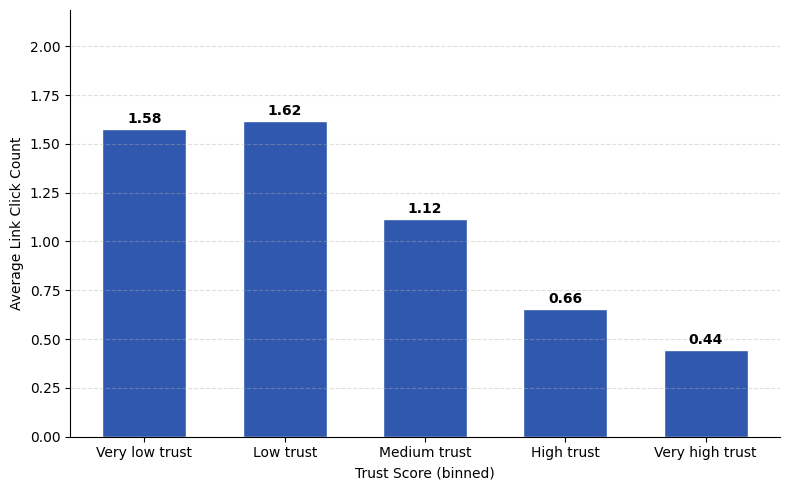

In [45]:
## bar chart of average link click count by trust scores
df_plot = df.copy()

df_plot["link_click_count"] = pd.to_numeric(df_plot["link_click_count"], errors="coerce")
df_plot = df_plot.dropna(subset=["trust_score", "link_click_count"])

# create bins 
df_plot["trust_bin"] = pd.qcut(
    df_plot["trust_score"],
    q=5,
    labels=[
        "Very low trust",
        "Low trust",
        "Medium trust",
        "High trust",
        "Very high trust"
    ]
)

summary = df_plot.groupby("trust_bin")["link_click_count"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    summary.index,
    summary.values,
    color="#3058AE",
    edgecolor="white",
    width=0.6
)

for i, val in enumerate(summary.values):
    ax.text(
        i,
        val + 0.03,
        f"{val:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("Trust Score (binned)")
ax.set_ylabel("Average Link Click Count")
ax.set_ylim(0, summary.max() * 1.35)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()